# 12 · Движок объяснимости LSI — банковский уровень

**Что это.** Полный движок объяснимости сигнала в любой точке: (1) **детальная атрибуция** «модули → драйверы → как формировался сигнал» с графиками от MAD-score до сырья; (2) **декомпозиция по компонентам** PCA (какие независимые факторы стресса активны); (3) **SHAP** для полного пайплайна (Scaler→PCA→IsolationForest) — золотой стандарт.

Функции в `utils.py`: `explain_lsi_point_full`, `explain_components_point`, `if_shap_point`. Демонстрируем на всплеске Local **2026-01-15** (LSI≈99) и для контраста — на спокойной дате.

> NL-комментарий (текст для аналитика) — отдельная фича на «потом»; здесь готовим под неё структурный вывод (топ-драйверы + направление + факторы), функционал `lsi_commentary_service` не трогаем.

## Setup

In [1]:
# --- bootstrap ---
import sys, os
from pathlib import Path
_here=Path.cwd(); _root=next((p for p in [_here,*_here.parents] if (p/'data'/'processed').is_dir()),_here)
os.chdir(_root); sys.path.insert(0,str(_root))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width',200); pd.set_option('display.max_columns',80)
import importlib
from lab import utils as u
importlib.reload(u)
print('project root:',_root.name)

project root: MathMode_LiquidityCatchers_RuLiquiditySentinel


In [2]:
d,GW,LW=u.build_honest_features(); dts=pd.to_datetime(d['date'])
loc=d[(dts>=dts.max()-pd.Timedelta(days=365))].reset_index(drop=True)
art=u.fit_lsi_like_model(loc,LW)
print('Local окно:',pd.to_datetime(loc['date']).min().date(),'->',pd.to_datetime(loc['date']).max().date(),'| фич:',len(LW))

Local окно: 2025-05-08 -> 2026-05-08 | фич: 26


/Users/nikitabaslykov/Documents/Работа/Казначейство/MathMode_LiquidityCatchers_RuLiquiditySentinel/lab/utils.py:986: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = raw.groupby(dc).apply(_agg).reset_index().rename(columns={dc: "date"})


## 1. Детальная атрибуция точки — `explain_lsi_point_full`

Печатает: LSI, **вклад модулей** (что привело к сигналу), **топ-драйверы** с `z` (насколько фича аномальна) и направлением. Рисует 4 панели формирования: LSI · драйверы (MAD) · вклад модулей во времени · сырьё #1 драйвера.

LSI на 2026-01-15 = 99.0
Вклад модулей: M1 43% (резервы/RUONIA), M3 25% (ОФЗ-аукционы), M2 17% (РЕПО-аукционы), M5 16% (ликвидность ЦБ/ЕКС)
Топ-драйверы (фича | вклад% | z | направление):
   m1_spread_vol                   12.1%  z=+2.96  ↑ выше нормы
   m1_spread_mad_score             11.1%  z=+1.96  ↑ выше нормы
   m1_spread_relative_mad_score    10.0%  z=+1.79  ↑ выше нормы
   m3x_placement                    6.6%  z=+1.25  ↑ выше нормы
   m1_reserve_load_mad_score        6.3%  z=-1.29  ↓ ниже нормы
   m3x_cover                        5.9%  z=+1.16  ↑ выше нормы
   m2_cutoff_spread                 5.5%  z=+1.37  ↑ выше нормы
   m5x_rk_bidders                   5.4%  z=+1.29  ↑ выше нормы


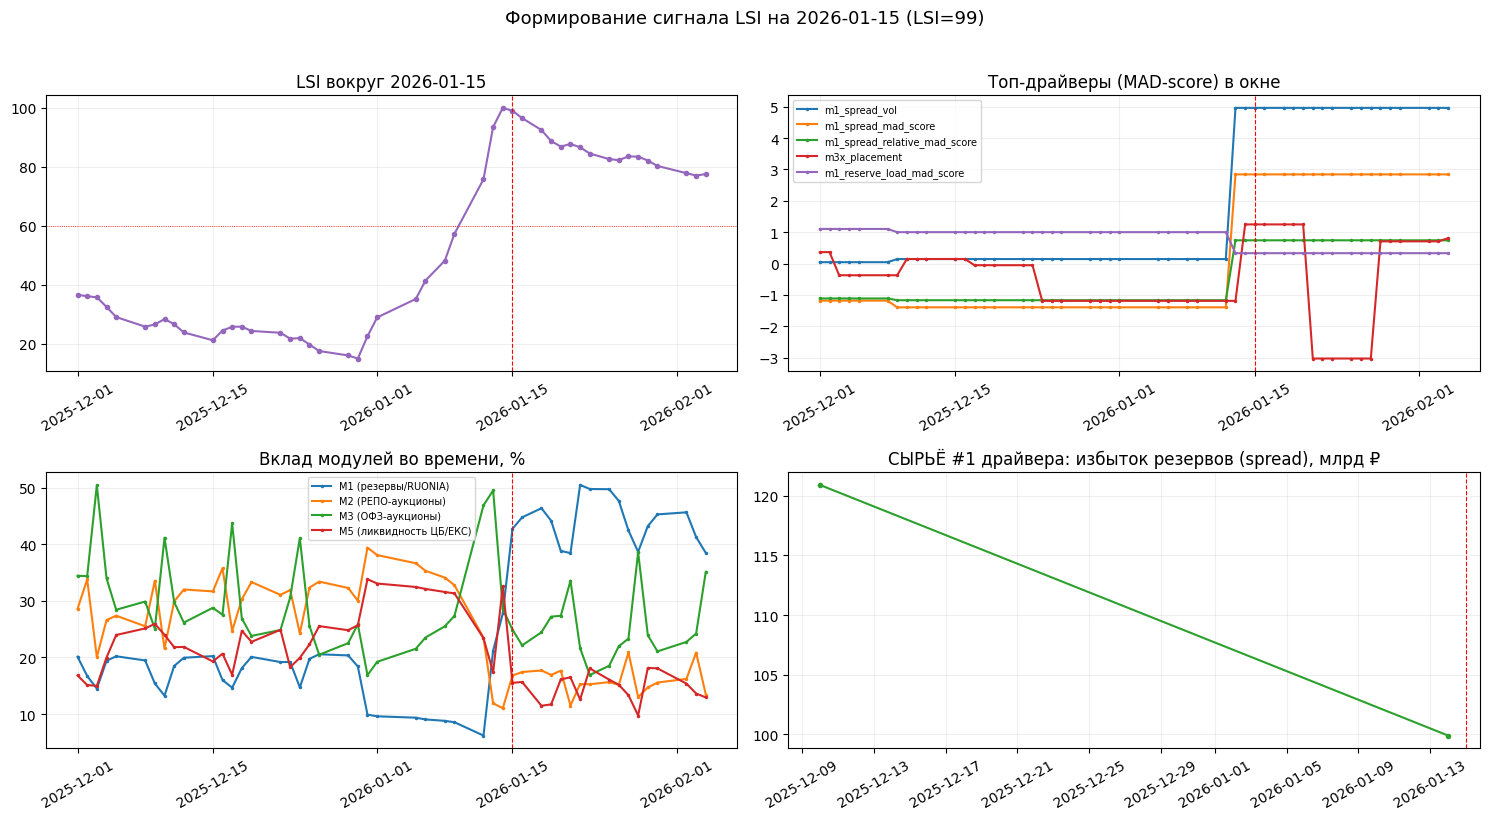

In [3]:
res=u.explain_lsi_point_full(art,loc,'2026-01-15',window_days=45,top_n=8); plt.show()

**Как читать.** Сверху сразу видно: сигнал на 2026-01-15 сформировали прежде всего **резервы (M1)** — `spread_vol` z≈3, `spread_mad` z≈2 (накопление/волатильность резервов), при поддержке ОФЗ (M3), премии РЕПО (M2) и спроса на средства ЕКС (M5). Панель «вклад модулей во времени» показывает **двухфазность**: сначала растёт M5 (новогодние кредиты ЦБ), затем M1 (резервы). Панель «сырьё» трассирует #1 драйвер к первичным числам из БД. Меняй дату — разбирай любую точку.

### Контраст: спокойная дата

In [4]:
calm=loc.iloc[int(np.argmin(np.abs(art['lsi']-art['lsi'].min())))]['date']
print('Спокойная дата:',pd.to_datetime(calm).date())
_=u.explain_lsi_point_full(art,loc,calm,window_days=45,top_n=6,make_plot=False)

Спокойная дата: 2026-04-27
LSI на 2026-04-27 = 0.0
Вклад модулей: M1 38% (резервы/RUONIA), M2 24% (РЕПО-аукционы), M5 22% (ликвидность ЦБ/ЕКС), M3 16% (ОФЗ-аукционы)
Топ-драйверы (фича | вклад% | z | направление):
   m1_ruonia_mad_score              9.9%  z=-1.68  ↓ ниже нормы
   m5x_claims                       9.5%  z=+1.57  ↑ выше нормы
   m1_spread_relative_mad_score     9.0%  z=+1.28  ↑ выше нормы
   m1_spread_mad_score              7.9%  z=+1.10  ↑ выше нормы
   m5x_rk_bidders                   7.7%  z=+1.48  ↑ выше нормы
   m2_short_active30                6.8%  z=+1.04  ↑ выше нормы


## 2. Декомпозиция по компонентам PCA — независимые факторы стресса

Сигнал стал многомерным, поэтому раскладываем его по компонентам: каждая PC — **независимый фактор** (по топ-loadings ему даётся экономический смысл), `активация_z` показывает, насколько фактор экстремален в точке. Так банк видит не только «какие фичи», но и «какие факторы».

In [5]:
display(u.explain_components_point(art,loc,'2026-01-15'))

,PC,EVR_%,активация_z,фактор(модуль),топ-loadings
0,PC1,27.8,-1.05,резервы/RUONIA,"m1_ruonia_mad_score(+0.35), m1_reserve_load_ma..."
1,PC2,15.0,-0.50,ОФЗ-аукционы,"m3x_days_since(+0.49), m3x_age(+0.49), m3_auct..."
2,PC3,9.4,1.99,РЕПО-аукционы,"m1_spread_vol(+0.52), m2_short_active30(-0.41)..."
3,PC4,8.1,0.74,ОФЗ-аукционы,"m2_cutoff_spread_available(+0.41), m5x_repostd..."
4,PC5,6.5,-0.35,ОФЗ-аукционы,"m3x_cover(+0.52), m3x_placement(+0.47), m1_spr..."


**Чтение (2026-01-15).** Активирован прежде всего **PC3 (z≈2)** — фактор «острый дефицит/волатильность» (топ-loadings: `m1_spread_vol`, `m2_short_active`, `m2_cutoff_spread`): резервы заколебались + РЕПО подорожало. PC1 (резервы/RUONIA-уровень) и PC2 (ОФЗ-активность) в этой точке менее экстремальны. Именно это «извлечение из 2-й/3-й компоненты», которое нужно для полной объяснимости.

## 3. SHAP для IsolationForest — золотой стандарт

`if_shap_point` строит SHAP на **полном пайплайне** `Scaler→PCA→IsolationForest` (KernelSHAP, per-feature вклад в anomaly-score). Сверяем с дешёвой EVR-attribution — должны согласовываться.

,SHAP_rank,EVR_rank
0,m1_spread_vol,m1_spread_vol
1,m1_spread_mad_score,m1_spread_mad_score
2,m5x_rk_bidders,m1_spread_relative_mad_score
3,m3x_yield_to_key,m3x_placement
4,m1_spread_relative_mad_score,m1_reserve_load_mad_score
5,m3x_placement,m3x_cover
6,m2_Flag_Demand,m2_cutoff_spread
7,m2_short_active30,m5x_rk_bidders
8,m3x_age,m2_short_active30
9,m3x_cover,m5x_secured


Топ-10 пересечение SHAP∩EVR: 7/10 фич; обе ставят #1 =True


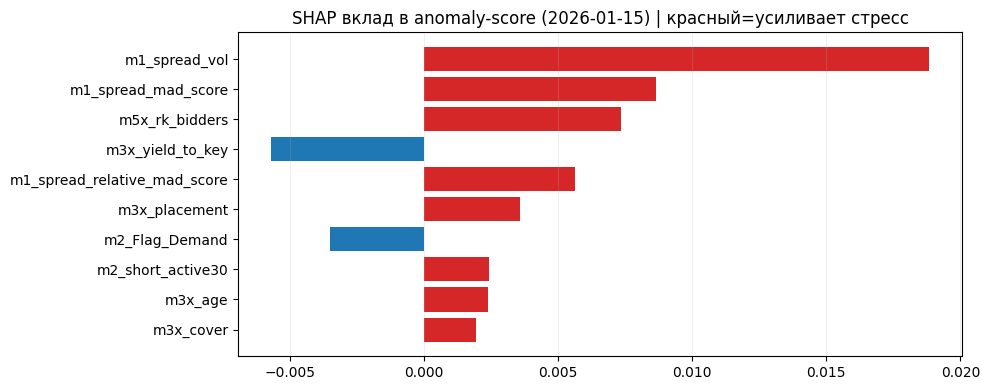

In [6]:
shap_s=u.if_shap_point(art,loc,'2026-01-15',top_n=10)
_,evr_tbl,_=u.explain_lsi_point(art,loc,'2026-01-15',top_n=10)
cmp=pd.DataFrame({'SHAP_rank':list(shap_s.index),'EVR_rank':list(evr_tbl.feature)})
display(cmp)
# ранговая согласованность по топ-драйверам
common=set(shap_s.index)&set(evr_tbl.feature)
print('Топ-10 пересечение SHAP∩EVR: %d/10 фич; обе ставят #1 =%s'%(len(common),shap_s.index[0]==evr_tbl.feature.iloc[0]))
fig,ax=plt.subplots(figsize=(10,4)); s=shap_s.iloc[::-1]
ax.barh(s.index,s.values,color=['tab:red' if v>0 else 'tab:blue' for v in s.values])
ax.set_title('SHAP вклад в anomaly-score (2026-01-15) | красный=усиливает стресс'); ax.grid(alpha=.2,axis='x'); plt.tight_layout(); plt.show()

**Вывод.** SHAP подтверждает EVR-attribution (оба ставят `m1_spread_vol` #1, `m1_spread_mad` #2) — объяснимость **робастна**: дешёвый EVR-метод можно использовать в проде на каждый запрос, а SHAP — как опциональный «глубокий аудит» (медленнее, но gold-standard).

## 3.1 Движок работает и на Global, и на Local (проверка)

Функции model-agnostic: принимают `(art, frame)` и читают `art['features']` динамически. Покажем тот же движок на **Global-модели** (вся история, набор `GW` без `rk_bidders`) на реальном кризисе **2022-03-01**.

**Правило использования:** передавать согласованную пару — Global: `fit_lsi_like_model(d, GW)` + полный `d`; Local: `fit_lsi_like_model(loc, LW)` + `loc`.

Global: rows=3077 | фич=25 | rk_bidders в наборе? False

LSI на 2022-03-01 = 40.7
Вклад модулей: M2 47% (РЕПО-аукционы), M5 25% (ликвидность ЦБ/ЕКС), M3 15% (ОФЗ-аукционы), M1 13% (резервы/RUONIA)
Топ-драйверы (фича | вклад% | z | направление):
   m2_auction_flag                 16.2%  z=+3.88  ↑ выше нормы
   m2_days_since_short              9.7%  z=-2.34  ↓ ниже нормы
   m2_short_active30                8.9%  z=+2.17  ↑ выше нормы
   m5x_claims                       8.2%  z=+1.93  ↑ выше нормы
   m5x_repostd                      7.9%  z=+2.13  ↑ выше нормы
   m1_spread_vol                    7.7%  z=+2.02  ↑ выше нормы
   m3x_available                    7.1%  z=-1.87  ↓ ниже нормы
   m5x_secured                      6.4%  z=+1.73  ↑ выше нормы


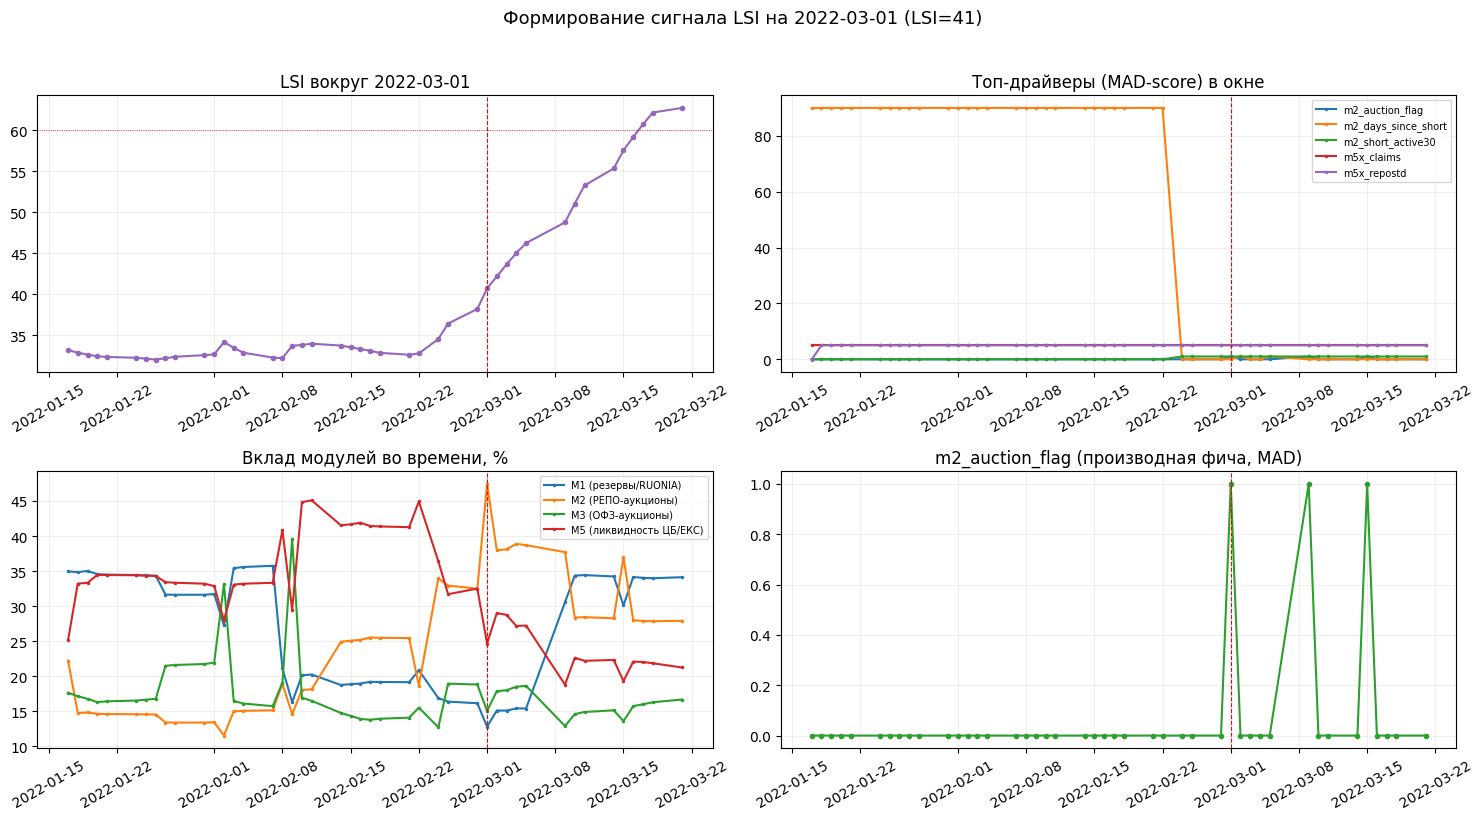

In [7]:
# GLOBAL-модель (вся история)
artG=u.fit_lsi_like_model(d,GW)
print('Global: rows=%d | фич=%d | rk_bidders в наборе? %s'%(len(d),len(GW),'m5x_rk_bidders' in artG['features']))
print()
# 1) детальная атрибуция на кризисе 2022-03-01
resG=u.explain_lsi_point_full(artG,d,'2022-03-01',window_days=45,top_n=8); plt.show()

In [8]:
# 2) компоненты и 3) SHAP на Global @ 2022-03-01
print('--- Компоненты (Global @ 2022-03-01) ---')
display(u.explain_components_point(artG,d,'2022-03-01').head(3))
print('--- SHAP top-6 (Global @ 2022-03-01) ---')
display(u.if_shap_point(artG,d,'2022-03-01',top_n=6).round(4))

--- Компоненты (Global @ 2022-03-01) ---


,PC,EVR_%,активация_z,фактор(модуль),топ-loadings
0,PC1,16.1,2.02,РЕПО-аукционы,"m3x_age(+0.43), m3x_available(-0.42), m2_days_..."
1,PC2,15.0,0.87,резервы/RUONIA,"m1_spread_relative_mad_score(+0.44), m1_spread..."
2,PC3,8.7,0.34,РЕПО-аукционы,"m3x_placement(+0.44), m3x_cover(+0.42), m2_bas..."


--- SHAP top-6 (Global @ 2022-03-01) ---


m2_auction_flag        0.0364
m5x_repostd            0.0183
m2_days_since_short    0.0175
m5x_claims             0.0141
m1_spread_vol          0.0129
m2_short_active30      0.0125
dtype: float64

**Вывод.** На Global движок работает в полном объёме: кризис 2022-03-01 корректно атрибутирован к **М2 (РЕПО-аукционы активны, `m2_auction_flag` z≈3.9)** + М5 (ЦБ кредитует банки) — экономически верно. Компоненты и SHAP согласованы. Тот же код, та же объяснимость — для обеих срочностей. _(Замечание: на Global 2026-01-15 даёт LSI≈33, а не 99 как на Local — Global нормирует по всей истории, где новогодний эпизод умереннее кризисов 2014/2022; драйверы те же.)_

## 4. Как это идёт в прод (Phase B)

- **На каждый запрос** `get_lsi_prediction`: отдавать `explain_lsi_point` (модули + топ-драйверы с `z` и направлением) — быстро, регуляторно-понятно.
- **Доп. поле**: `explain_components_point` (активные факторы PC) — раскрывает многомерность.
- **Глубокий режим** (по кнопке/для аудита): `if_shap_point` — SHAP per-feature.
- **Графики** `explain_lsi_point_full` — для дашборда «почему всплеск» (формирование сигнала от сырья).
- **NL-комментарий** — позже: структурный вывод (драйверы+направление+факторы) уже готов под `lsi_commentary_service`, его не трогаем.

**Итог:** объяснимость доведена до банковского уровня — от модулей и драйверов до компонент, сырья и SHAP, с подтверждённой робастностью. Любую точку сигнала можно объяснить по фактам и нарисовать.